In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

raw = pd.read_csv('appstore_games.csv')
print('Columns,rows:', raw.shape)
raw.head(3)

Columns,rows: (17007, 18)


,URL,ID,Name,Subtitle,Icon_URL,Average_User_Rating,User_Rating_Count,Price,In_app_Purchases,Description,Developer,Age_Rating,Languages,Size,Primary_Genre,Genres,Original_Release_Date,Current_Version_Release_Date
0,https://apps.apple.com/us/app/sudoku/id284921427,284921427,Sudoku,NaN,https://is2-ssl.mzstatic.com/image/thumb/Purpl...,4.0,3553.0,2.99,NaN,"Join over 21,000,000 of our fans and download ...",Mighty Mighty Good Games,4+,"DA, NL, EN, FI, FR, DE, IT, JA, KO, NB, PL, PT...",15853568.0,Games,"Games, Strategy, Puzzle",11/7/2008,30/05/2017
1,https://apps.apple.com/us/app/reversi/id284926400,284926400,Reversi,NaN,https://is4-ssl.mzstatic.com/image/thumb/Purpl...,3.5,284.0,1.99,NaN,"The classic game of Reversi, also known as Oth...",Kiss The Machine,4+,EN,12328960.0,Games,"Games, Strategy, Board",11/7/2008,17/05/2018
2,https://apps.apple.com/us/app/morocco/id284946595,284946595,Morocco,NaN,https://is5-ssl.mzstatic.com/image/thumb/Purpl...,3.0,8376.0,0.00,NaN,Play the classic strategy game Othello (also k...,Bayou Games,4+,EN,674816.0,Games,"Games, Board, Strategy",11/7/2008,5/9/2017


In [76]:
games = raw.drop_duplicates().copy()
print('Number of games after de-duplicating:', len(games))

games['price'] = games['Price'].fillna(0) #điền 0 vào null
games['rating_count'] = games['User_Rating_Count'].fillna(0)

games['has_iap'] = games['In_app_Purchases'].notna()

games['release_date'] = pd.to_datetime(games['Original_Release_Date'], format='%d/%m/%Y')
games['release_year'] = games['release_date'].dt.year

Number of games after de-duplicating: 16847


In [77]:
games['model'] = 'free_no_iap'
games.loc[games['has_iap'], 'model'] = 'free_iap'
games.loc[games['price'] > 0, 'model'] = 'paid'

games['model'].value_counts()

,count
model,
free_no_iap,7067
free_iap,7041
paid,2739


In [78]:
p90 = games['rating_count'].quantile(0.9)
print('Top 10% threhold:', p90)

games['tier'] = 'rated'
games.loc[games['rating_count'] >= p90, 'tier'] = 'top_10pct'
games.loc[games['rating_count'] == 0, 'tier'] = 'no_rating'

games['is_top10'] = games['tier'] == 'top_10pct'
games['is_no_rating'] = games['tier'] == 'no_rating'


games['tier'].value_counts()

Top 10% threhold: 404.7999999999993


,count
tier,
no_rating,9359
rated,5803
top_10pct,1685


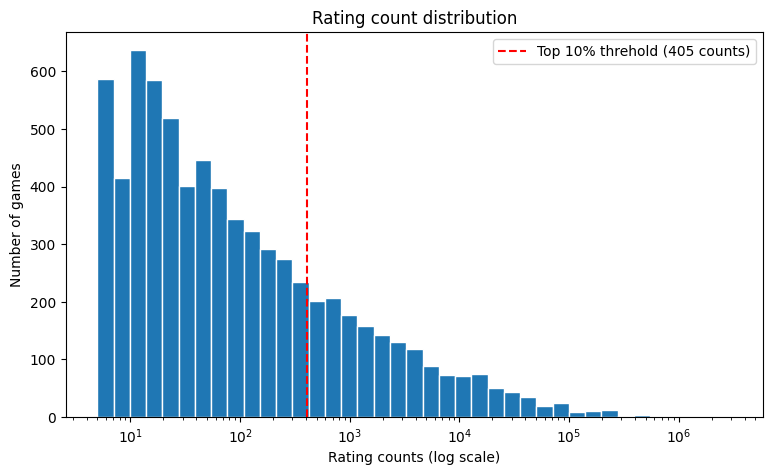

In [79]:
rated_games = games[games['rating_count'] > 0]

plt.figure(figsize=(9, 5))
plt.hist(rated_games['rating_count'], bins=bins, edgecolor='white')

plt.axvline(p90, color='red', linestyle='--', label=f'Top 10% threhold (405 counts)')
plt.title('Rating count distribution')
plt.xscale('log')
plt.xlabel('Rating counts (log scale)')
plt.ylabel('Number of games')
plt.legend()
plt.show()

In [80]:
tier_table = games.groupby('tier').agg(
    games=('ID', 'count'),
    ratings=('rating_count', 'sum')
)
tier_table['pct_games'] = (100 * tier_table['games'] / tier_table['games'].sum()).round(1)
tier_table['pct_ratings'] = (100 * tier_table['ratings'] / tier_table['ratings'].sum()).round(1)

tier_table

,games,ratings,pct_games,pct_ratings
tier,,,,
no_rating,9359,0.0,55.6,0.0
rated,5803,361324.0,34.4,1.5
top_10pct,1685,24395837.0,10.0,98.5


In [84]:
model_table = games.groupby('model').agg(
    games=('ID', 'count'),
    top_games=('is_top10', 'sum'),
    no_rating_games=('is_no_rating', 'sum')
)
model_table['pct_games'] = (100 * model_table['games'] / model_table['games'].sum()).round(1)
model_table['pct_of_top10'] = (100 * model_table['top_games'] / model_table['top_games'].sum()).round(1)
model_table['hit_rate'] = (100 * model_table['top_games'] / model_table['games']).round(1)
model_table['pct_no_rating'] = (100 * model_table['no_rating_games'] / model_table['games']).round(1)

model_table.sort_values('hit_rate', ascending=False)

,games,top_games,no_rating_games,pct_games,pct_of_top10,hit_rate,pct_no_rating
model,,,,,,,
free_iap,7041,1169,2830,41.8,69.4,16.6,40.2
paid,2739,310,1520,16.3,18.4,11.3,55.5
free_no_iap,7067,206,5009,41.9,12.2,2.9,70.9
